In [1]:
print("it should work")

[1] "it should work"


In [3]:
library(dplyr)
library(tidyr)
library(readr)
library(caret)
library(ggplot2)
library(gplots)
library(GGally)

[1] "check now"


In [7]:
df = read.csv("C:/Users/lenovo/Downloads/heart.csv")
head(df)

#dimension of the dataset
dim(df)

#getting the summary of the dataset
summary(df)

#getting information about the dataframe
str(df)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>
1,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
2,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
3,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
4,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
5,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0
6,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1


[1] 1025   14

      age             sex               cp            trestbps    
 Min.   :29.00   Min.   :0.0000   Min.   :0.0000   Min.   : 94.0  
 1st Qu.:48.00   1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.:120.0  
 Median :56.00   Median :1.0000   Median :1.0000   Median :130.0  
 Mean   :54.43   Mean   :0.6956   Mean   :0.9424   Mean   :131.6  
 3rd Qu.:61.00   3rd Qu.:1.0000   3rd Qu.:2.0000   3rd Qu.:140.0  
 Max.   :77.00   Max.   :1.0000   Max.   :3.0000   Max.   :200.0  
      chol          fbs            restecg          thalach     
 Min.   :126   Min.   :0.0000   Min.   :0.0000   Min.   : 71.0  
 1st Qu.:211   1st Qu.:0.0000   1st Qu.:0.0000   1st Qu.:132.0  
 Median :240   Median :0.0000   Median :1.0000   Median :152.0  
 Mean   :246   Mean   :0.1493   Mean   :0.5298   Mean   :149.1  
 3rd Qu.:275   3rd Qu.:0.0000   3rd Qu.:1.0000   3rd Qu.:166.0  
 Max.   :564   Max.   :1.0000   Max.   :2.0000   Max.   :202.0  
     exang           oldpeak          slope             ca        
 Min.   :

'data.frame':	1025 obs. of  14 variables:
 $ age     : int  52 53 70 61 62 58 58 55 46 54 ...
 $ sex     : int  1 1 1 1 0 0 1 1 1 1 ...
 $ cp      : int  0 0 0 0 0 0 0 0 0 0 ...
 $ trestbps: int  125 140 145 148 138 100 114 160 120 122 ...
 $ chol    : int  212 203 174 203 294 248 318 289 249 286 ...
 $ fbs     : int  0 1 0 0 1 0 0 0 0 0 ...
 $ restecg : int  1 0 1 1 1 0 2 0 0 0 ...
 $ thalach : int  168 155 125 161 106 122 140 145 144 116 ...
 $ exang   : int  0 1 1 0 0 0 0 1 0 1 ...
 $ oldpeak : num  1 3.1 2.6 0 1.9 1 4.4 0.8 0.8 3.2 ...
 $ slope   : int  2 0 0 2 1 1 0 1 2 1 ...
 $ ca      : int  2 0 0 1 3 0 3 1 0 2 ...
 $ thal    : int  3 3 3 3 2 2 1 3 3 2 ...
 $ target  : int  0 0 0 0 0 1 0 0 0 0 ...


age      sex       cp trestbps     chol      fbs  restecg  thalach 
       0        0        0        0        0        0        0        0 
   exang  oldpeak    slope       ca     thal   target 
       0        0        0        0        0        0

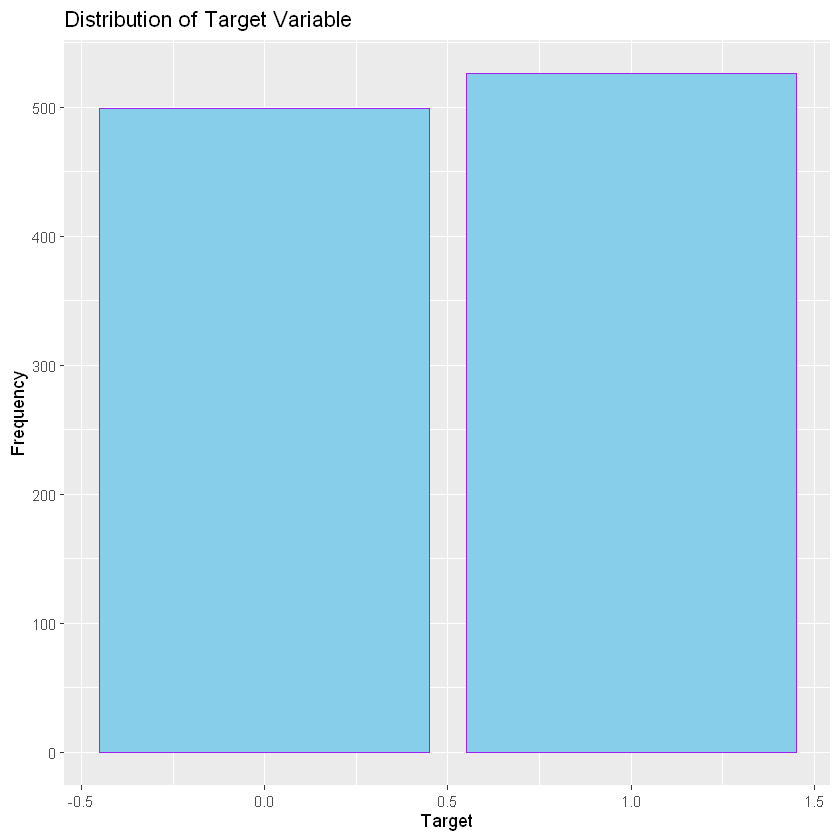

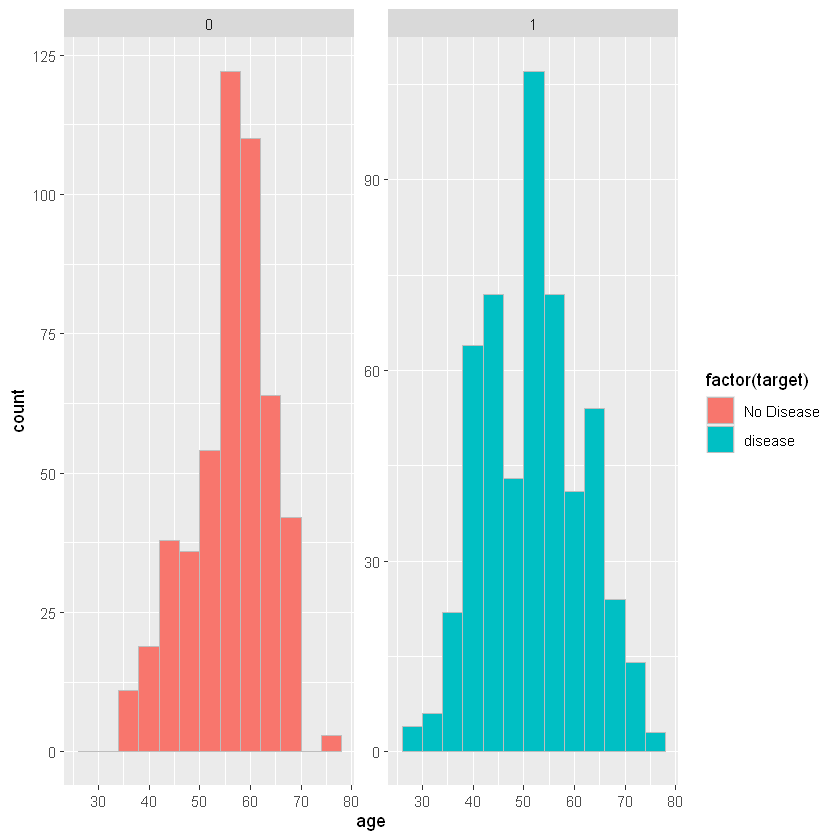

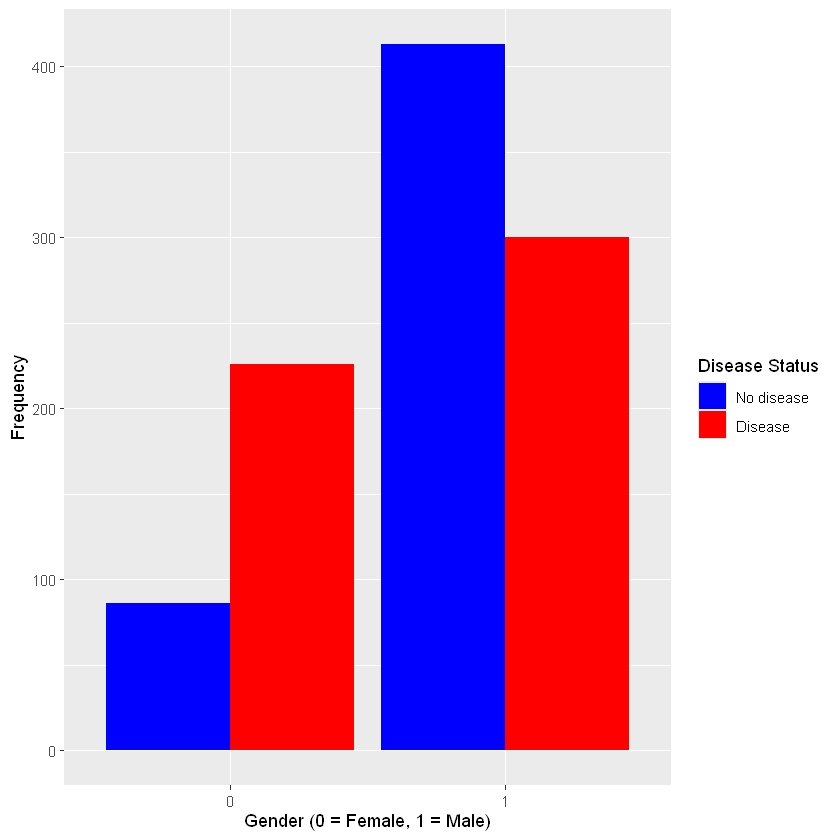

In [9]:
# Exploratory data analysis 
# performing basic EDA on heart data 

#count missing values in each column
colSums(is.na(df))


#visualizing the distribution of the target variable 
ggplot(df, aes(x = target)) + geom_bar(fill = 'skyblue', color = 'purple', stat = "count") + labs(title = "Distribution of Target Variable", x = "Target", y = "Frequency")

#now we will plot a histogram to show the relation between heart diseases and and age
ggplot(df, aes(x= age, fill = factor(target))) + geom_histogram(binwidth = 4, position = "dodge", color = "grey") + facet_wrap(~target, scales = "free_y") + scale_fill_discrete(labels = c("No Disease", "disease"))



# next we will try to find a relation between gender and heart disease 
ggplot(df, aes(x = factor(sex), fill = factor(target))) +
  geom_bar(position = "dodge") +
  labs(
    x = "Gender (0 = Female, 1 = Male)",
    y = "Frequency",
    fill = "Disease Status"
  ) +
  scale_fill_manual(
    values = c("0" = "blue", "1" = "red"),
    labels = c("No disease", "Disease")
  )


'data.frame':	1025 obs. of  14 variables:
 $ age     : int  52 53 70 61 62 58 58 55 46 54 ...
 $ sex     : Factor w/ 2 levels "0","1": 2 2 2 2 1 1 2 2 2 2 ...
 $ cp      : Factor w/ 4 levels "0","1","2","3": 1 1 1 1 1 1 1 1 1 1 ...
 $ trestbps: int  125 140 145 148 138 100 114 160 120 122 ...
 $ chol    : int  212 203 174 203 294 248 318 289 249 286 ...
 $ fbs     : Factor w/ 3 levels "0","1","2": 2 1 2 2 2 1 3 1 1 1 ...
 $ restecg : int  1 0 1 1 1 0 2 0 0 0 ...
 $ thalach : int  168 155 125 161 106 122 140 145 144 116 ...
 $ exang   : Factor w/ 2 levels "0","1": 1 2 2 1 1 1 1 2 1 2 ...
 $ oldpeak : num  1 3.1 2.6 0 1.9 1 4.4 0.8 0.8 3.2 ...
 $ slope   : Factor w/ 3 levels "0","1","2": 3 1 1 3 2 2 1 2 3 2 ...
 $ ca      : Factor w/ 5 levels "0","1","2","3",..: 3 1 1 2 4 1 4 2 1 3 ...
 $ thal    : Factor w/ 5 levels "0","1","2","3",..: 3 1 1 2 4 1 4 2 1 3 ...
 $ target  : Factor w/ 2 levels "0","1": 1 1 1 1 1 2 1 1 1 1 ...


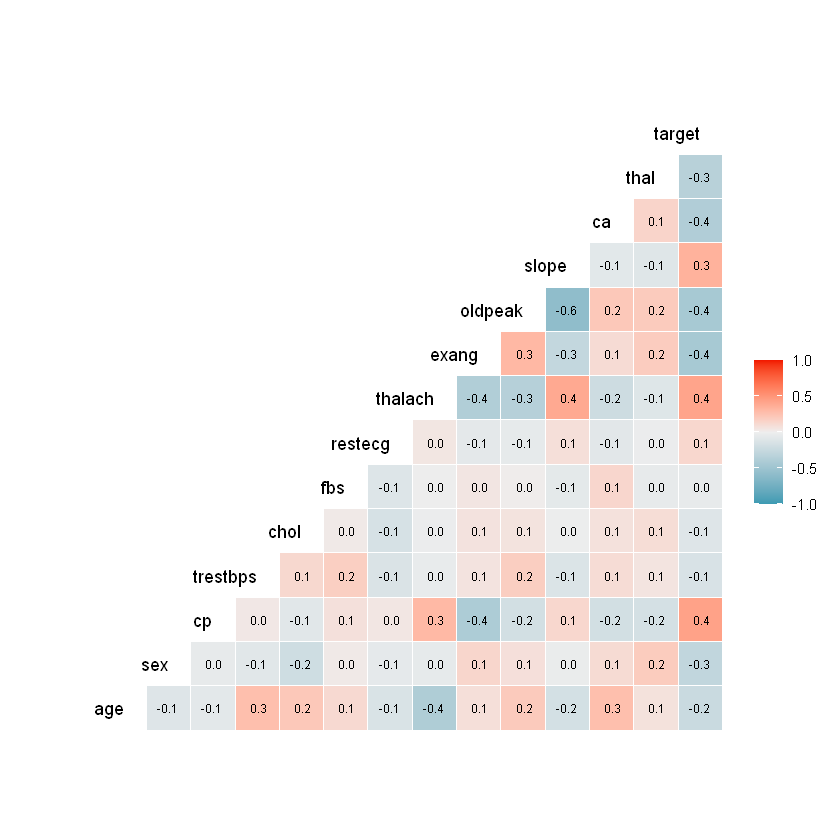

In [12]:
#correlation matrix 
ggcorr(df, label = TRUE, label_size = 2.5, hjust = 1, layout.exp = 2)



#Exploratory Data Analysis reveals that certain factors like gender, type of chest pain, fasting blood sugar level, etc. are categorical 
#variables and are not suitable for model training. We will encode these variables into "factor" data type in R for organized and improved 
#understanding of this information. This encoding allows for efficient handling of categorical variables in statistical models and data analysis.

heart = df %>% 
  mutate(sex = as.factor(sex),
         cp = as.factor(cp), 
         fbs = as.factor(restecg),
         exang = as.factor(exang),
         slope = as.factor(slope),
         ca = as.factor(ca),
         thal = as.factor(ca),
         target = as.factor(target)
         )
str(heart)


# normalization and data splitting 
#at first we will select the features with higher relation with target
#variable. then perform data normalizaion for stable and faster training of
#logistic regression model, after that we split the data into 80% for training 
#and 20% data is for prediction purpose 



#feature selection
features = df[, c('age', 'sex',  'cp', 'trestbps', 'chol', 'restecg', 'thalach', 
                   'exang', 'oldpeak', 'slope', 'ca', 'thal')]
target = df$target

preprocessParams = preProcess(features, method = c("center", "scale"))
features_normalized = predict(preprocessParams, features)



In [13]:
#splitting the data
split = createDataPartition(target, p = 0.8, list = FALSE)
X_train = features_normalized[split, ]
X_test = features_normalized[-split, ]
Y_train = target[split]
Y_test = target[-split]

#shape of the training and test sets
print(paste("X_train shape:", paste(dim(X_train), collapse = 'x')))
print(paste("X_test shape:", paste(dim(X_test), collapse = "x")))


#Now that we have our data normalized and split into train and test sets,
#we are ready to train the Logistic Regression model on this data.


train_data = as.data.frame(cbind(target = Y_train, X_train))

#training logistic regression model
model = glm(target ~ ., data= train_data, family = "binomial")



[1] "X_train shape: 820x12"
[1] "X_test shape: 205x12"


Confusion Matrix and Statistics

          Reference
Prediction  0  1
         0 78 15
         1 20 92
                                          
               Accuracy : 0.8293          
                 95% CI : (0.7706, 0.8781)
    No Information Rate : 0.522           
    P-Value [Acc > NIR] : <2e-16          
                                          
                  Kappa : 0.6571          
                                          
 Mcnemar's Test P-Value : 0.499           
                                          
            Sensitivity : 0.8598          
            Specificity : 0.7959          
         Pos Pred Value : 0.8214          
         Neg Pred Value : 0.8387          
             Prevalence : 0.5220          
         Detection Rate : 0.4488          
   Detection Prevalence : 0.5463          
      Balanced Accuracy : 0.8279          
                                          
       'Positive' Class : 1               
                                    

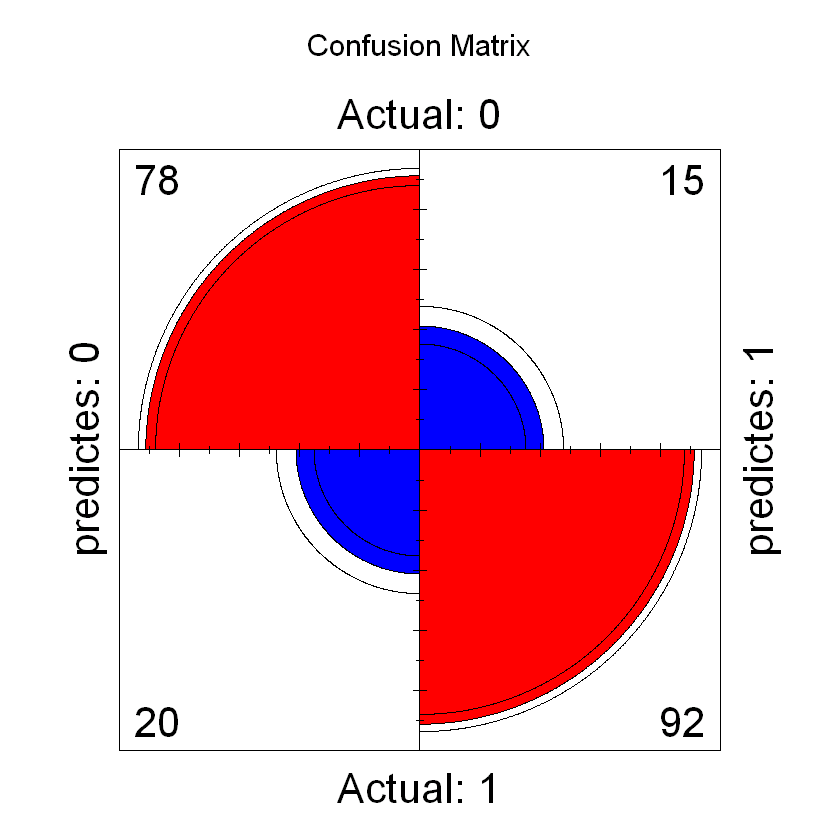

In [14]:
#making orediction on the test set

prediction = predict(model, newdata = as.data.frame(X_test), type = "response")


binary_prediciton = ifelse(prediction >= 0.5, 1, 0)

result = data.frame(actual = Y_test, predicted = binary_prediciton)



confusionMatrix(data = as.factor(binary_prediciton), reference = as.factor(Y_test), positive = "1")



#create a confusion matrix
conf_matrix = table(factor(binary_prediciton, levels = c("0", "1")), factor(Y_test, levels = c("0", "1")))

#setting dimensions
dimnames(conf_matrix) = list(Actual = c("0","1"), predictes = c("0","1"))

#plot the fourthfold plot with color main title
fourfoldplot(conf_matrix, color = c("blue", "red"), main = "Confusion Matrix")
